## Notebook 3 - Dimensionality Reduction

### 1. Exploratory Data Analysis +  Features Insight

#### Imports

In [81]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import (PCA, TruncatedSVD)
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 24

In [2]:
# Importing dataframe from Notebook 1

df_sample = pd.read_csv('enriched_marketing_sample.csv')

df_sample.head()

,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score,clusters,agg_clusters,db_clusters,ms_clusters
0,11906.880747,62427,0.021087,1263,10.701997,438.254852,18.194972,2,2,2,0,3
1,36306.065526,478661,0.041990,20999,1.742935,123.141463,21.936816,7,3,0,1,1
2,36039.772545,608496,0.038142,23702,1.476780,149.700788,23.916203,7,3,0,1,1
3,9182.470640,29637,0.017813,505,17.702593,475.003554,33.068893,2,2,2,0,3
4,39417.315326,635976,0.044160,29147,1.301943,60.987286,26.207460,7,3,0,1,1


In [3]:
df_sample.nunique()

ad_budget                1000
impressions              1000
ctr                      1000
clicks                    963
cpc                      1000
time_on_site             1000
user_engagement_score    1000
device_score                9
clusters                    4
agg_clusters                4
db_clusters                 5
ms_clusters                 5
dtype: int64

In [4]:
print('Dataframe Structure:\n')
df_sample.info()

Dataframe Structure:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ad_budget              1000 non-null   float64
 1   impressions            1000 non-null   int64  
 2   ctr                    1000 non-null   float64
 3   clicks                 1000 non-null   int64  
 4   cpc                    1000 non-null   float64
 5   time_on_site           1000 non-null   float64
 6   user_engagement_score  1000 non-null   float64
 7   device_score           1000 non-null   int64  
 8   clusters               1000 non-null   int64  
 9   agg_clusters           1000 non-null   int64  
 10  db_clusters            1000 non-null   int64  
 11  ms_clusters            1000 non-null   int64  
dtypes: float64(5), int64(7)
memory usage: 93.9 KB


In [5]:
print('Summary Statistics:\n')
df_sample.iloc[:,:8].describe()

Summary Statistics:



,ad_budget,impressions,ctr,clicks,cpc,time_on_site,user_engagement_score,device_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,28842.488723,318633.292000,0.032599,11970.404000,5.726853,282.432417,43.175452,4.418000
std,12063.635010,202568.185155,0.009771,8930.881134,6.520893,150.925630,21.892743,2.112283
min,2218.654353,4420.000000,0.012715,88.000000,1.211501,18.941861,7.767439,1.000000
25%,21567.309771,129064.250000,0.023638,3580.750000,1.823267,143.856074,27.132435,2.750000
50%,33654.552194,327104.000000,0.035408,11715.500000,2.757850,309.389575,35.687459,4.000000
75%,38514.984708,484671.500000,0.041760,19266.250000,7.067458,420.685792,61.957155,6.000000
max,47423.208837,769124.000000,0.049585,35633.000000,67.397543,600.000000,96.397941,9.000000


### 2. PCA (Principle Components Analysis)

**Principal Component Analysis (PCA)** is an unsupervised machine learning technique used for dimensionality reduction.

Our marketing dataset had 8 distinct feature columns (dimensions). Human brains cannot visualise an 8-dimensional space. **PCA** fixes this by rotating and crushing that 8D space down into fewer, new dimensions called **_Principal Components (PCs)_**. However, compressing data always comes with a cost: information loss (variance). Variance plot acts as our financial ledger, showing exactly how much of your original 8D data's patterns we keep as we move from 1 component up to 8.

#### Helper function: _cumulative_variance_plot_

In [6]:
def cumulative_variance_plot(pca_model, threshold = 0.9):

    # calculating the rolling cumulative sum of the variance ratios
    cumulative_variance = np.cumsum(pca_model.explained_variance_ratio_)
    num_components = len(cumulative_variance)

    plt.figure(figsize = (10,6))

    #Plotting the Variance Curve
    plt.plot(range(1, num_components + 1), cumulative_variance, marker = 'o', linestyle = '--', color = 'darkblue',
             label = 'Cumulative Variance Captured'
            )

    plt.axhline(y = threshold, linestyle = ':', color = 'crimson',
                label = f'{int(threshold*100)}% Information Threshold'
               )

    plt.title('PCA Cumulative Explained Variance Diagnostic Plot', fontweight = 'bold')
    plt.xlabel('Number of Principal Components Selected')
    plt.ylabel('Cumulative Proportion of Total Variance')
    plt.xticks(range(1, num_components + 1))
    plt.ylim(0.6, 1.05)
    plt.grid(True, linestyle = ':', alpha = 0.6)
    plt.legend()

    # Looping through each marker point to annotate the exact Percentage value
    for i, val in enumerate(cumulative_variance):
        # data point plot features
        plt.text(i + 1, val + 0.02, f'{val*100:.1f}%', fontweight = 'semibold', color = 'black')

    plt.tight_layout()
    plt.show()

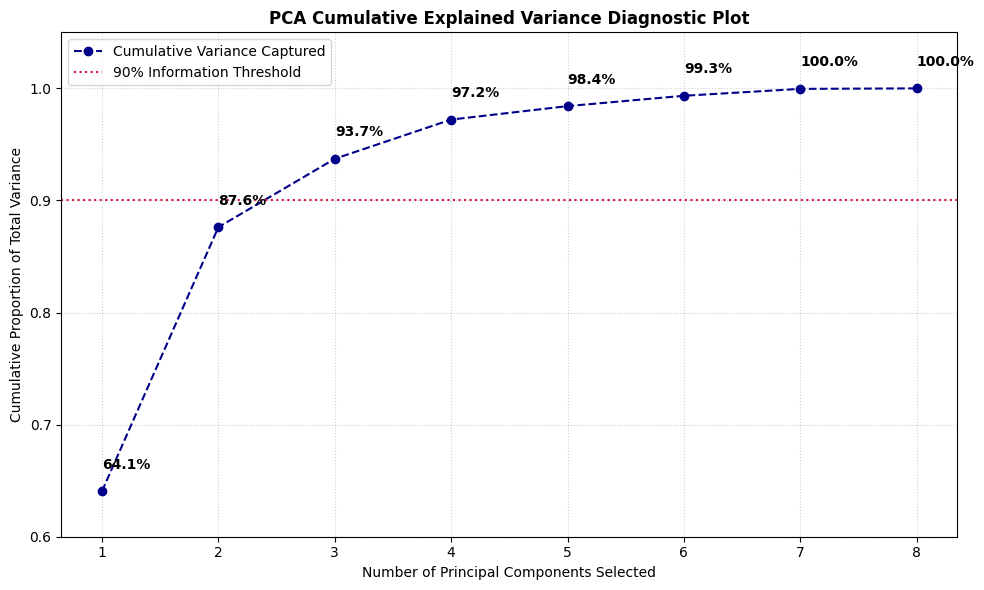

In [7]:
marketing_features = [
    'ad_budget', 'impressions', 'ctr', 'clicks', 'cpc', 'time_on_site', 'user_engagement_score', 'device_score'
]

features_only = df_sample[marketing_features]
# isolating the cluster columns from being treated as marketing matrics when training models

df_scaled = StandardScaler().fit_transform(features_only)
# applying Standard Scaling to eliminate feature dominance

pca_baseline = PCA(
    n_components = 8,
    random_state = 24
)

pca_baseline.fit(df_scaled)

cumulative_variance_plot(pca_baseline, threshold = 0.9)

### 3. PCA 2D Projection [PC1 & PC2]

In [8]:
# building a new PCA model for 2 components only

pca_2d = PCA(
    n_components = 2,
    random_state = 24
)

pca_coordinates = pca_2d.fit_transform(df_scaled)

df_sample['PC1'] = pca_coordinates[:, 0]
df_sample['PC2'] = pca_coordinates[:, 1]

print('Original Scaled Matrix Shape:', df_scaled.shape)
print('New PCA Coordinate Array Shape:', pca_coordinates.shape)
print('\nPreviewing new 2D coordinate space:')

df_sample[['PC1', 'PC2']].head()

Original Scaled Matrix Shape: (1000, 8)
New PCA Coordinate Array Shape: (1000, 2)

Previewing new 2D coordinate space:


,PC1,PC2
0,-3.115571,-0.349650
1,2.197341,-1.277466
2,2.402865,-1.215359
3,-3.849713,-0.027592
4,3.269961,-1.188196


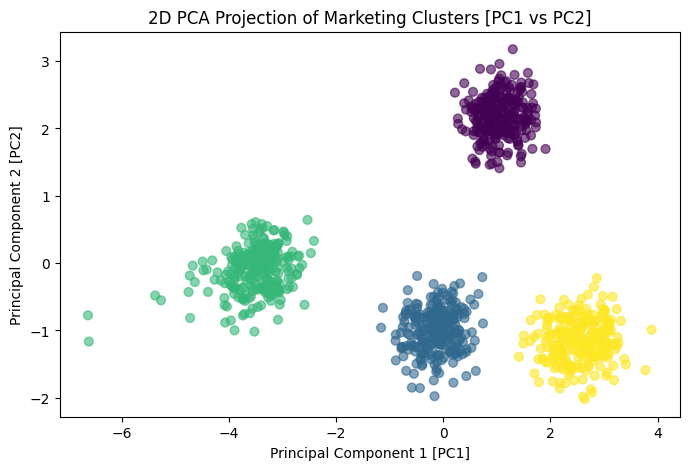

In [9]:
plt.figure(figsize = (8,5))

plt.scatter(df_sample['PC1'], df_sample['PC2'], c = df_sample['clusters'], s = 40, alpha = 0.6)

plt.title('2D PCA Projection of Marketing Clusters [PC1 vs PC2]')
plt.xlabel('Principal Component 1 [PC1]')
plt.ylabel('Principal Component 2 [PC2]')
plt.plot();

### 4. PCA 3D Projection [PC1, PC2, PC3]

In [10]:
# building a new PCA model for 3 components only

pca_3d = PCA(
    n_components = 3,
    random_state = 24
)

pca_3d_coordinates = pca_3d.fit_transform(df_scaled)

df_sample['PC3'] = pca_3d_coordinates[:, 2]

df_sample[['PC1', 'PC2', 'PC3']].head()

,PC1,PC2,PC3
0,-3.115571,-0.349650,0.348304
1,2.197341,-1.277466,0.415846
2,2.402865,-1.215359,0.675393
3,-3.849713,-0.027592,0.520136
4,3.269961,-1.188196,0.859188


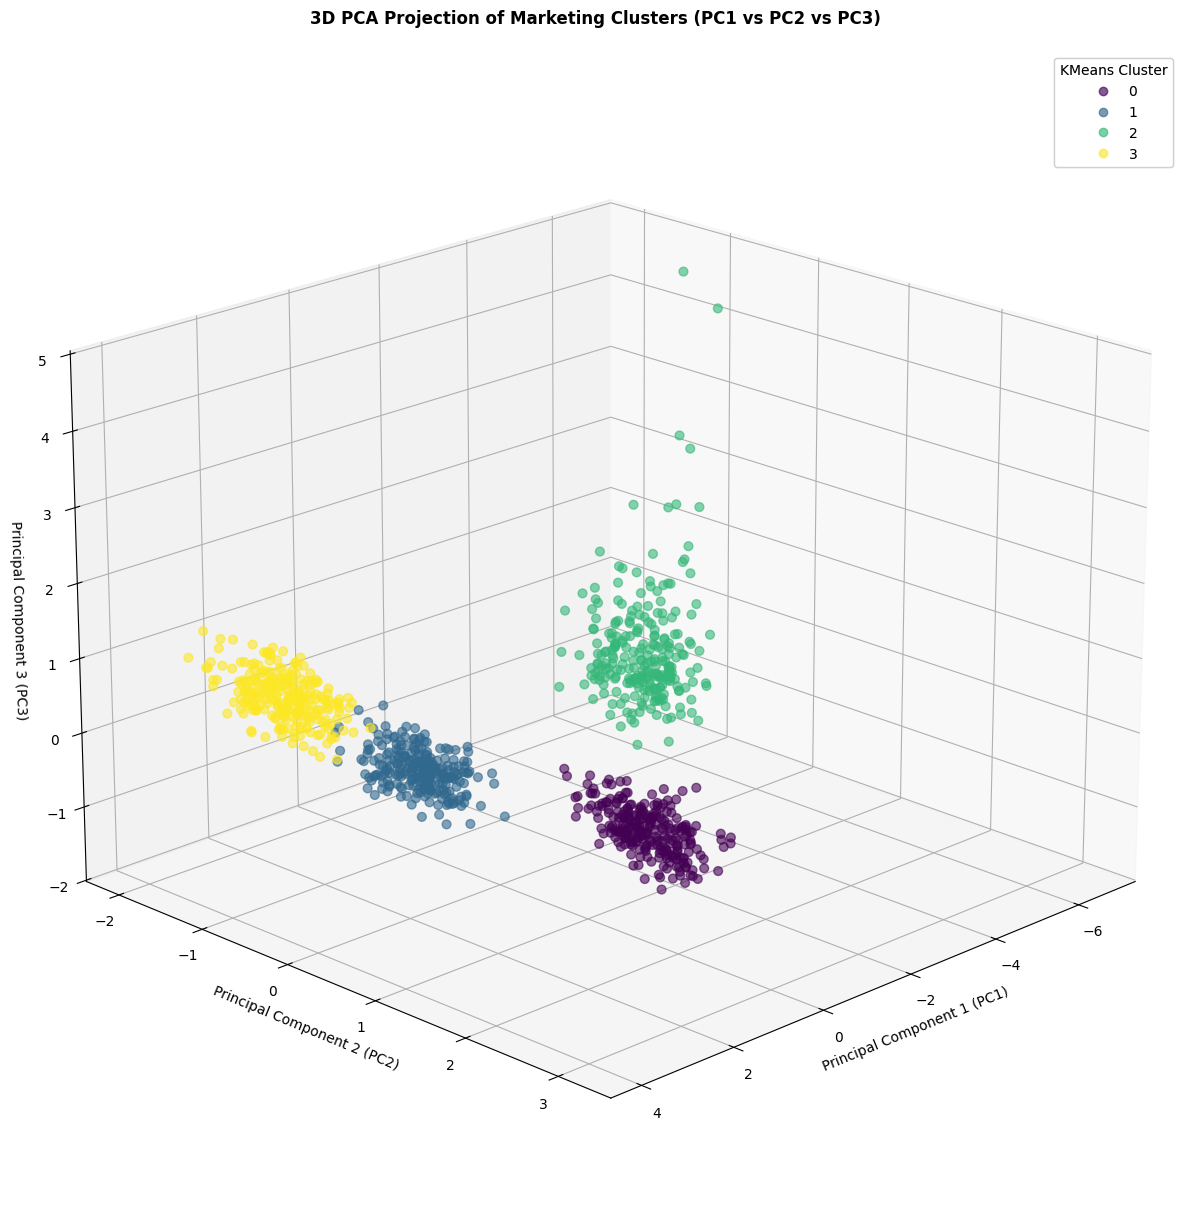

In [11]:
# Intiating a 3d plotting curve

fig = plt.figure(figsize = (12,16))

ax = fig.add_subplot(1, 1, 1, projection = '3d')

scatter_3d = ax.scatter(df_sample['PC1'], df_sample['PC2'], df_sample['PC3'], c = df_sample['clusters'], s = 40, alpha = 0.6)

ax.set_title('3D PCA Projection of Marketing Clusters (PC1 vs PC2 vs PC3)', fontweight='bold', pad=20)
ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')

# adding the cluster color legend
legend_3d = ax.legend(*scatter_3d.legend_elements(), title = 'KMeans Cluster', loc = 'upper right')
ax.add_artist(legend_3d)

# Adjust the initial viewing angle for the best visual perspective (elevation=20, azimuth=45)
ax.view_init(elev = 20, azim = 45)

plt.tight_layout()
plt.show();

### 5. Singular Value Decomposition (SVD)

__SVD__ is a fundamental theorem in linear algebra. It states that any real matrix X (like our 1000 × 8 standardised marketing matrix) can be broken down (factored) into three distinct, smaller matrices multiplied together.

$U$ (Left Singular Vectors / Column-Space): This matrix maps our 1,000 campaign rows to an abstract coordinate space.

$Σ$ (Singular Values / The Weights): This is a diagonal matrix containing numbers sorted from largest to smallest. These numbers represent the strength or significance of each component.

$(VT)$ (Right Singular Vectors / Row-Space): This matrix maps our 8 marketing features to the components. This is the exact matrix of _PCA Loadings_ — the recipe that explains how much weights of ad_budget or clicks are needed to construct PC1 and PC2.

#### SVD Study Example

In [15]:
# Matrix Example
a = np.array([[3,2], [2,3]])

print(a)

[[3 2]
 [2 3]]


In [18]:
# Singular Value Decomposition
U, S, VT = np.linalg.svd(a)

print('Left Singular Vectors (U):\n', U)
print('\nSingular Values (S):', S)
print('\nRight Singular Vectors (VT):\n', VT)

Left Singular Vectors (U):
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]

Singular Values (S): [5. 1.]

Right Singular Vectors (VT):
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


In [36]:
# Reconstructing Matrix

sigma = np.zeros(a.shape)

sigma[:2, :2] = np.diag(S)

reconstructed_a = U @ sigma @ VT

reconstructed_a

array([[3., 2.],
       [2., 3.]])

**Truncated SVD vs. Standard PCA**:

**_Standard PCA_** works by calculating a covariance matrix first, which forces the data to be centered around a mean of 0.

**_TruncatedSVD_** runs the matrix factorisation directly on the data without forcing it to center first. It is called _'Truncated'_ because we can command it to only calculate the top K components and ignore the rest, making it fast and memory-efficient.

In [38]:
# TruncatedSVD targetting 2 components only
svd = TruncatedSVD(
    n_components = 2,
    random_state = 24
)

svd_coordinates = svd.fit_transform(df_scaled)

df_sample['SVD1'] = svd_coordinates[:, 0]
df_sample['SVD2'] = svd_coordinates[:, 1]

print('Original Scaled Matrix Shape:', df_scaled.shape)
print('New SVD Coordinate Array Shape:', svd_coordinates.shape)
print('\nPreviewing new 2D coordinate space:')

df_sample[['SVD1', 'SVD2']].head()

Original Scaled Matrix Shape: (1000, 8)
New SVD Coordinate Array Shape: (1000, 2)

Previewing new 2D coordinate space:


,SVD1,SVD2
0,-3.115571,-0.349650
1,2.197341,-1.277466
2,2.402865,-1.215359
3,-3.849713,-0.027592
4,3.269961,-1.188196


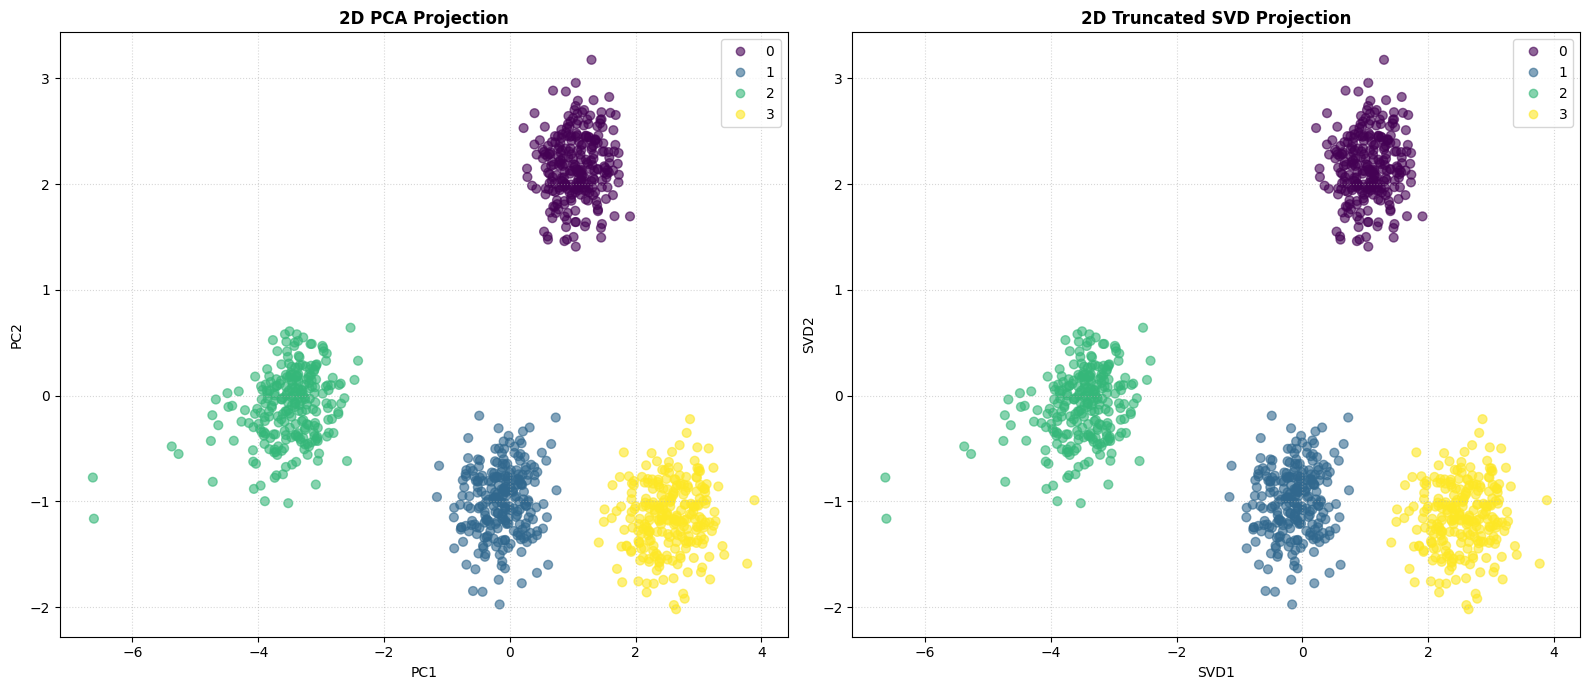

In [41]:
# Plotting SVD Space next to PCA space

fit, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 7))

# Left plot: PCA Map
scatter_pca = ax1.scatter(df_sample['PC1'], df_sample['PC2'], c = df_sample['clusters'], s = 40, alpha = 0.6)
ax1.set_title('2D PCA Projection', fontweight = 'bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(linestyle = ':', alpha = 0.5)

# Right plot: SVD Map
scatter_svd = ax2.scatter(df_sample['SVD1'], df_sample['SVD2'], c = df_sample['clusters'], s = 40, alpha = 0.6)
ax2.set_title('2D Truncated SVD Projection', fontweight = 'bold')
ax2.set_xlabel('SVD1')
ax2.set_ylabel('SVD2')
ax2.grid(linestyle = ':', alpha = 0.5)

ax1.legend(*scatter_pca.legend_elements(), loc = 'upper right')
ax2.legend(*scatter_svd.legend_elements(), loc = 'upper right')

plt.tight_layout()
plt.show();

### 6. PCA Image Compression Analysis

Original Image Shape (3D array): (1080, 1920, 3)
Length of Original Image Matrix: 3

Matrix Structure: 1080 rows (pixels) by 1920 columns (features)


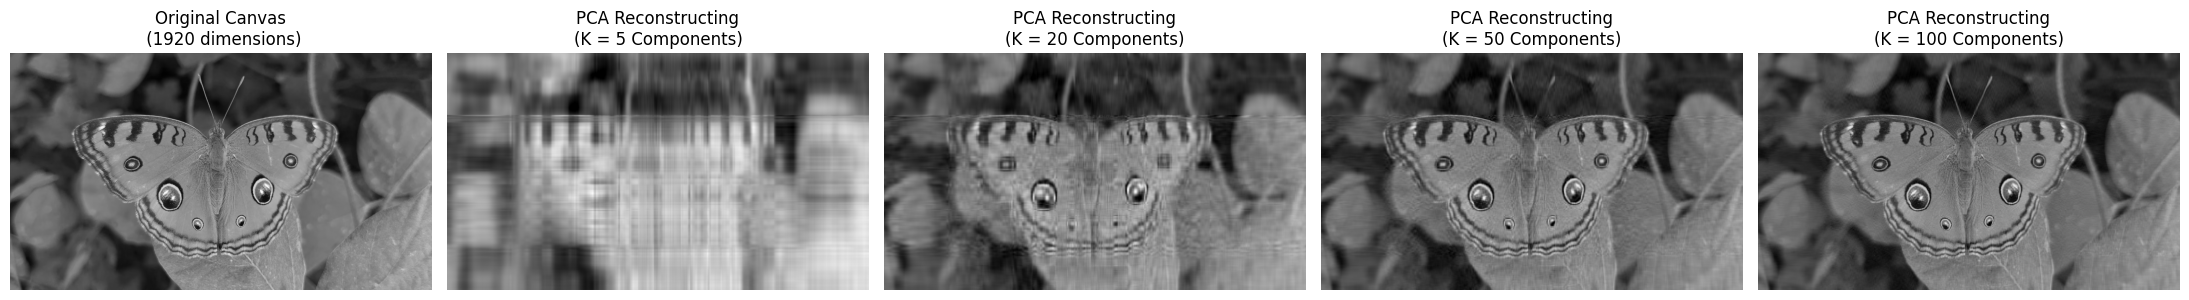

In [79]:
# Loading an image from local folder
img_raw = plt.imread('butterfly.png')
print('Original Image Shape (3D array):', img_raw.shape)
print('Length of Original Image Matrix:', len(img_raw.shape))

# Converting to greyscale if image in color to reduce complexity when running PCA
if len(img_raw.shape) == 3:
    # Averaging the third position of color to reduce color complexity
    img_gray = np.mean(img_raw, axis = 2)

else:
    img_gray = img_raw.copy()

# Ensuring image matrix has floating-point decimals for smooth PCA
img_gray = img_gray.astype(np.float64)
max_dimensions = img_gray.shape[1]

print(f'\nMatrix Structure: {img_gray.shape[0]} rows (pixels) by {max_dimensions} columns (features)')

# Defining Component cuts
component_cuts = [5, 20, 50, 100]

# Initiating a 1x5 plot
fig, axes = plt.subplots(1, 5, figsize = (22,5))

# plotting the original image at position 0
axes[0].imshow(img_gray, cmap = 'gray')
axes[0].set_title(f'Original Canvas\n ({max_dimensions} dimensions)')
axes[0].axis('off')

# Iterating remaining plots
for idx, k in enumerate(component_cuts):

    if k > max_dimensions:
        continue
        # Safety check to prevent crashing if image is much smaller

    # Using PCA to bring top k recipes
    pca_img = PCA(
        n_components = k,
        random_state = 24
    )

    # Compressing img_gray into tighter subspace
    low_dim_features = pca_img.fit_transform(img_gray)

    # Mapping low_dimensional data back into original image
    reconstructed_matrix = pca_img.inverse_transform(low_dim_features)

    # Clipping pixel boundary [0 to 255]
    reconstructed_matrix = np.clip(reconstructed_matrix, 0, 255)

    # Targeting next plot box in grid
    ax = axes[idx + 1]
    ax.imshow(reconstructed_matrix, cmap = 'gray')
    ax.set_title(f'PCA Reconstructin\n(K = {k} Components)')
    ax.axis('off')

plt.tight_layout()
plt.show();

### 7. t-SNE

**_CA_** and **_Truncated SVD_** are strictly linear methods. They assume that our 8-dimensional marketing space can be flattened by simply drawing straight perpendicular lines through the data. While this works well for clean, dense clusters, linear methods completely fail if data is folded, curved, or twisted. 

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a non-linear, distance-based algorithm. 

Instead of looking at global variances, it works entirely on a probabilistic neighborhood map:

In the 8D Space: It measures the distance between every pair of points and converts that distance into a probability score representing how likely they are to be 'neighbors'.

In the 2D Space: It plots the points randomly on a flat 2D canvas. It then checks their new 2D neighborhood probabilities and starts shifting the points iteratively.

The Non-Linear Magic: It uses a Student-t distribution to create a 'gravitational pull'. It actively pulls close neighbors into incredibly tight, dense islands while pushing completely different groups far away from each other. Because it bends and stretches the space to preserve local neighborhoods rather than global straight lines, it reveals cluster structures that PCA physically cannot see.

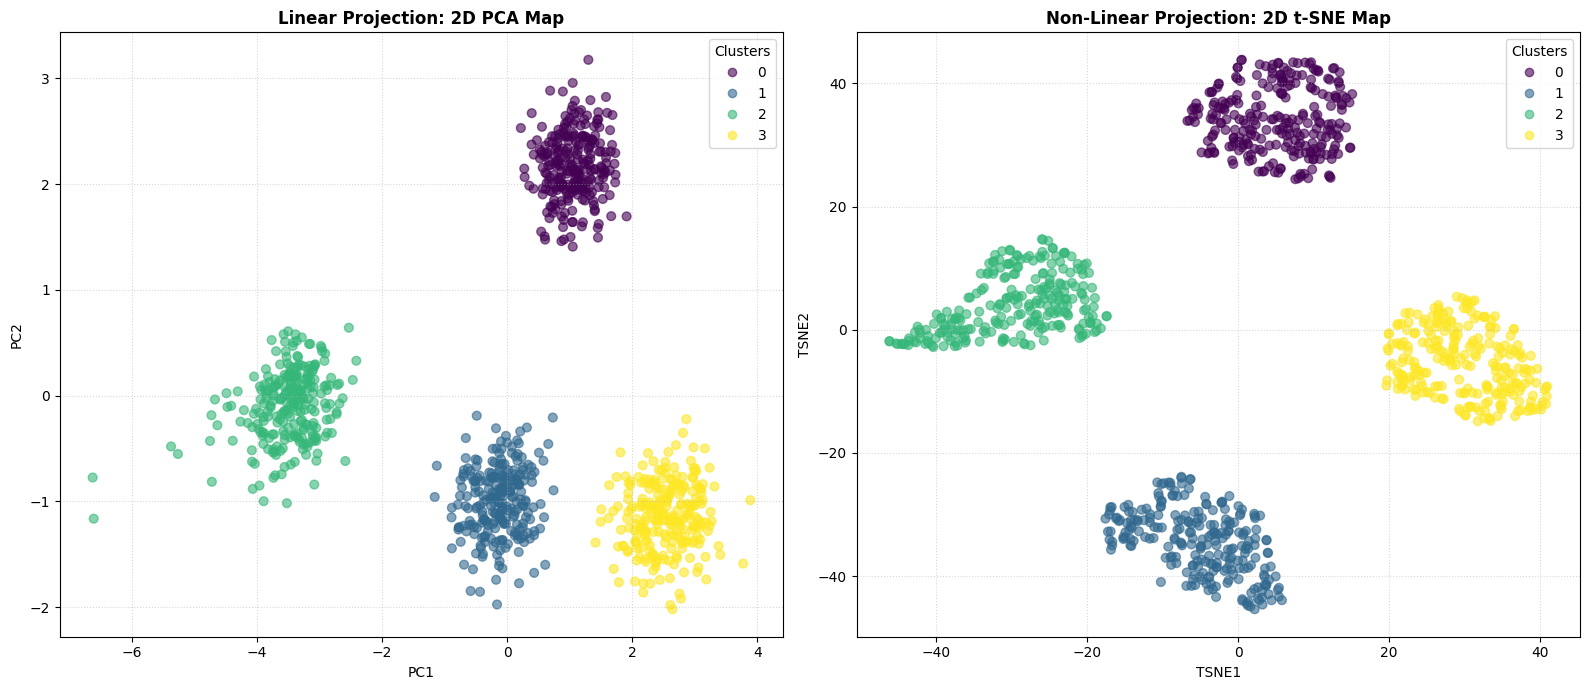

In [85]:
# Applying t-SNE model for non-linear plotting
tsne_model = TSNE(
    n_components = 2,
    perplexity = 30,
    #'perplexity' balances local vs global attention (30 is the industry standard)
    random_state = 24,
    max_iter = 1000
)

tsne_coordinates = tsne_model.fit_transform(df_scaled)

df_sample['TSNE1'] = tsne_coordinates[:, 0]
df_sample['TSNE2'] = tsne_coordinates[:, 1]

# Plotting PCA vs t-SNE side-by-side for linear vs non-linear mapping
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16,7))

scatter_pca = ax1.scatter(df_sample['PC1'], df_sample['PC2'], c = df_sample['clusters'], s = 40, alpha = 0.6)
ax1.set_title('Linear Projection: 2D PCA Map', fontweight = 'bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True, linestyle = ':', alpha = 0.5)

scatter_tsne = ax2.scatter(df_sample['TSNE1'], df_sample['TSNE2'], c = df_sample['clusters'], s = 40, alpha = 0.6)
ax2.set_title('Non-Linear Projection: 2D t-SNE Map', fontweight = 'bold')
ax2.set_xlabel('TSNE1')
ax2.set_ylabel('TSNE2')
ax2.grid(True, linestyle = ':', alpha = 0.5)

ax1.legend(*scatter_pca.legend_elements(), title = 'Clusters', loc = 'upper right')
ax2.legend(*scatter_tsne.legend_elements(), title = 'Clusters', loc = 'upper right')

plt.tight_layout()
plt.show();

**Key takeaway**

Our side-by-side visualisation reveals a stark architectural contrast in how linear and non-linear mapping engines interpret our 8-dimensional marketing funnel:

* **The Linear Perspective (2D PCA):** PCA projects our dataset by finding global directions of maximum variance. While it successfully separates the core bodies of our four campaign personas, it suffers from the 'crowding problem' at the margins.High-variance border campaigns appear squashed and merged together along the cluster boundaries, as a linear plane cannot fully untangle overlapping multi-dimensional frontiers.


* **The Non-Linear Perspective (2D t-SNE):** t-SNE completely revolutionises the spatial layout. By discarding global variance limits and focussing entirely on preserving local probabilistic neighbourhoods (via `perplexity=30`), it resolves the crowding problem. The Student-t distribution applies an organic clustering force—drawing similar campaigns into ultra-dense, tight islands while aggressively pushing different segments apart.

#### Final Synthesis:
The massive 'white background oceans' separating our four t-SNE islands provide definitive structural proof that our marketing segments are highly distinct. While PCA is superior for preserving raw mathematical variance for compression, t-SNE is the undisputed champion for visualising and verifying cluster boundaries in unstructured machine learning.

In [87]:
# Save the increased sample containing marketing features, clustering labels, PCA, and t-SNE coordinates
df_sample.to_csv("master_marketing_reduced.csv", index=False)